# Temporal Multiplex Directed Networks for the Semiconductor Industry

A Temporal Multiplex Directed Network $\mathcal{M}$ is defined as a sequence of layers $L = \{L_1, L_2, \dots, L_M\}$, where each layer represents a different type of interaction (Financial, Supply Chain, etc.) over time steps $t \in \{1, \dots, T\}$.

The state of the network at any time $t$ is represented by a Supra-Adjacency Tensor $\mathcal{A}$: $$\mathcal{A}_{i,j, \alpha}(t)$$
Where: 
$i, j \in \{1, \dots, N\}$ are the semiconductor companies (nodes). 
$\alpha \in \{1, \dots, M\}$ is the specific layer (e.g., $\alpha=1$ for the Financial Layer, $\alpha=2$ for the Supply Chain Layer, $\alpha=3$ for the Ownership Layer). $t$ is the temporal window (e.g., the specific week).

In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
sys.path.append('..')
import numpy as np
import pandas as pd
import yfinance as yf
import plotly.express as px
import matplotlib.pyplot as plt
import networkx as nx
from py_scripts.project2 import financial_layer as fl

## Financial Layer

TODO WRITE A SUMMARY OF THE STEPS DONE AND WHAT WAS ACHIEVED


### DATA ACQUISITION

In [11]:



foundries = {
    "TSM": "Taiwan Semiconductor Manufacturing Company Limited",
    "SMSN.IL": "Samsung Electronics Co., Ltd.",
    "INTC": "Intel Corporation",
    "UMC": "United Microelectronics Corporation",
    "GFS": "GlobalFoundries Inc.",
    "0981.HK": "Semiconductor Manufacturing International Corporation",
}

fabless_designers = {
    "NVDA": "NVIDIA Corporation",
    "AMD": "Advanced Micro Devices, Inc.",
    "AVGO": "Broadcom Inc.",
    "ARM": "Arm Holdings plc",
    "QCOM": "QUALCOMM Incorporated",
    "2454.TW": "MediaTek Inc.",
    "MRVL": "Marvell Technology, Inc.",
    "ALAB": "Astera Labs, Inc.",
}

memory = {
    "MU": "Micron Technology, Inc.",
    "000660.KS": "SK Hynix Inc.",
}

wfe = {
    "ASML": "ASML Holding N.V.",
    "AMAT": "Applied Materials, Inc.",
    "LRCX": "Lam Research Corporation",
    "KLAC": "KLA Corporation",
    "8035.T": "Tokyo Electron Limited",
    "6857.T": "Advantest Corporation",
    "TER": "Teradyne, Inc.",
    "6920.T": "Lasertec Corporation",
    "SNPS": "Synopsys, Inc.",
    "CDNS": "Cadence Design Systems, Inc.",
}

osat_packaging = {
    "3711.TW": "ASE Technology Holding Co., Ltd.",
    "AMKR": "Amkor Technology, Inc.",
    "042700.KS": "Hanmi Semiconductor Co., Ltd.",
}

analog_auto_power = {
    "TXN": "Texas Instruments Incorporated",
    "ADI": "Analog Devices, Inc.",
    "NXPI": "NXP Semiconductors N.V.",
    "STNE": "STMicroelectronics N.V.",
    "ON": "ON Semiconductor Corporation",
    "IFX.DE": "Infineon Technologies AG",
    "MCHP": "Microchip Technology Incorporated"
}

# Organize spheres
spheres = {
    "Foundries": foundries,
    "Fabless Designers": fabless_designers,
    "Memory": memory,
    "WFE (Equipment)": wfe,
    "OSAT & Packaging": osat_packaging,
    "Analog/Auto/Power": analog_auto_power,
}



In [24]:
# Download and visualize each sphere with 3h interval
for sphere_name, tickers_dict in spheres.items():
    data = yf.download(list(tickers_dict.keys()), start="2023-01-01", prepost=False, progress=False)['Close']
    
    fig = px.line(data.reset_index(), x='Date', y=data.columns,
                  title=f'{sphere_name} - Close Price (Since 2023, 3h Intervals)',
                  labels={'value': 'Close Price (USD)', 'variable': 'Ticker'})
    fig.update_layout(xaxis_title='Date', yaxis_title='Price (USD)')
    fig.show()

In [ ]:
# Compute and visualize returns for each sphere
total_returns = pd.DataFrame()
for sphere_name, tickers_dict in spheres.items():
    data = yf.download(list(tickers_dict.keys()), start="2024-01-01", interval='1h', prepost=False, progress=False)['Close']
    returns = np.log(data / data.shift(1)).dropna()
    total_returns = pd.concat([total_returns, returns], axis=1)

    fig = px.line(returns.reset_index(), x='Date', y=returns.columns,
                  title=f'{sphere_name} - Returns (Since 2024, 1h Intervals)',
                  labels={'value': 'Returns', 'variable': 'Ticker'})
    fig.update_layout(xaxis_title='Date', yaxis_title='Returns')
    fig.show()

C:\Users\Youdas Yessad\AppData\Local\Temp\ipykernel_38720\3583276182.py:6: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  total_returns = pd.concat([total_returns, returns], axis=1)


C:\Users\Youdas Yessad\AppData\Local\Temp\ipykernel_38720\3583276182.py:6: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  total_returns = pd.concat([total_returns, returns], axis=1)


C:\Users\Youdas Yessad\AppData\Local\Temp\ipykernel_38720\3583276182.py:6: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  total_returns = pd.concat([total_returns, returns], axis=1)


C:\Users\Youdas Yessad\AppData\Local\Temp\ipykernel_38720\3583276182.py:6: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  total_returns = pd.concat([total_returns, returns], axis=1)


### Breaking Symmetry in the Financial Layer

To transform a standard undirected correlation into a Directed Lead-Lag Network, we define the directed adjacency matrix $A^{(dir)}$ using a time-shifted correlation.

For any two assets $i$ and $j$, the directed edge weight $E_{i \to j}$ is calculated as:$$E_{i \to j}(t) = \text{corr}(R_{i, t}, R_{j, t+1})$$
Conversely, the influence of $j$ on $i$ is:$$E_{j \to i}(t) = \text{corr}(R_{j, t}, R_{i, t+1})$$
In this construction, $A^{(dir)}$ is asymmetric ($E_{i \to j} \neq E_{j \to i}$), representing the directional flow of information from a "leader" to a "lagger."

In [54]:
window = 38*2 # T/N ratio of 2 for the Marchenko-Pastur filtering
graphs = []

total_returns_list = total_returns.dropna()
# Apply Marchenko-Pastur filtering in a weekly rolling window
for i in range(window, len(total_returns_list), 5):
    window_slice = total_returns_list.iloc[i-window : i]
    current_date = total_returns_list.index[i]
    assym_corr_matrix = fl.assymetrical_correlation_matrix(window_slice)
    print("RETARD RETARD")
    print(assym_corr_matrix)
    clipped_corr_matrix = fl.marchenko_pastur_returns(assym_corr_matrix, window, len(window_slice))
    
    graph = nx.from_pandas_adjacency(clipped_corr_matrix, create_using=nx.DiGraph)
    graphs.append((current_date, graph))

graphs_df = pd.DataFrame(graphs, columns=['Date', 'Graph'])
graphs_df.info()
graphs_df.head()

RETARD RETARD
Ticker      0981.HK       GFS      INTC   SMSN.IL       TSM       UMC  \
Ticker                                                                  
0981.HK   -0.066513  0.032291 -0.008976  0.095066  0.004108 -0.034891   
GFS        0.134117 -0.075360  0.064761  0.074189 -0.095757 -0.125074   
INTC       0.213397  0.037102  0.115588  0.316956 -0.056423 -0.112464   
SMSN.IL   -0.059146  0.067059  0.208081  0.114781  0.003051  0.034793   
TSM        0.136546 -0.156335 -0.002724  0.202848 -0.108295 -0.175891   
UMC        0.074388 -0.203577 -0.059049  0.042968 -0.154132 -0.161171   
2454.TW    0.137096  0.202612  0.298960  0.324166  0.083499  0.164757   
ALAB      -0.014412 -0.184975 -0.009864 -0.020093 -0.076593 -0.230536   
AMD        0.009164 -0.112286  0.086439  0.045496  0.032100 -0.075817   
ARM        0.069201  0.074268  0.240755  0.235986  0.046093 -0.128333   
AVGO       0.110419 -0.066121  0.059814  0.134503 -0.023459 -0.187828   
MRVL       0.060201 -0.107893  0.0438

,Date,Graph
0,2024-09-04,"(0981.HK, GFS, INTC, SMSN.IL, TSM, UMC, 2454.T..."
1,2024-09-13,"(0981.HK, GFS, INTC, SMSN.IL, TSM, UMC, 2454.T..."
2,2024-09-30,"(0981.HK, GFS, INTC, SMSN.IL, TSM, UMC, 2454.T..."
3,2024-10-18,"(0981.HK, GFS, INTC, SMSN.IL, TSM, UMC, 2454.T..."
4,2024-10-25,"(0981.HK, GFS, INTC, SMSN.IL, TSM, UMC, 2454.T..."


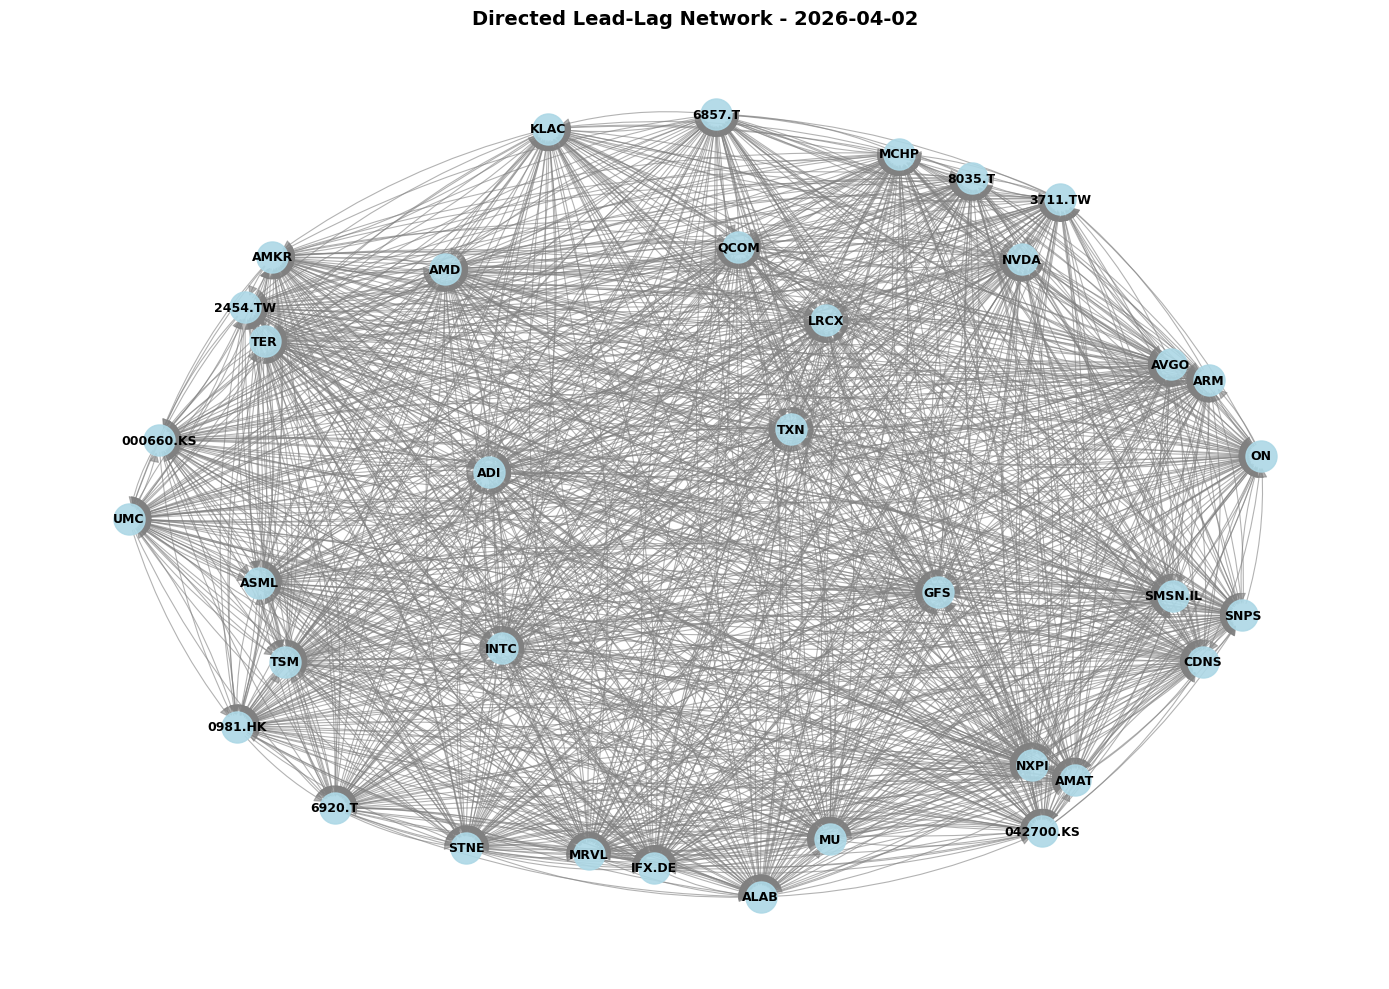

In [55]:
# Visualize the last graph for sanity check
last_date, last_graph = graphs_df.iloc[-1]

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(last_graph, k=0.5, iterations=50)
nx.draw_networkx_nodes(last_graph, pos, node_color='lightblue', node_size=500, alpha=0.9)
nx.draw_networkx_labels(last_graph, pos, font_size=9, font_weight='bold')
nx.draw_networkx_edges(last_graph, pos, edge_color='gray', arrows=True, arrowsize=15, 
                       width=0.8, connectionstyle='arc3,rad=0.1', alpha=0.6)
plt.title(f'Directed Lead-Lag Network - {last_date.date()}', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

In [56]:
#visualize the denoised correlation matrix
plt.figure(figsize=(12, 10))
plt.imshow(C_final_df, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Denoised Correlation')
plt.title('Denoised Correlation Matrix of Semiconductor Stocks')
plt.xticks(ticks=np.arange(len(C_final_df.columns)), labels=C_final_df.columns, rotation=90) 
plt.yticks(ticks=np.arange(len(C_final_df.index)), labels=C_final_df.index)
plt.tight_layout()

NameError: name 'C_final_df' is not defined

<Figure size 1200x1000 with 0 Axes>